### How well do jobs and skills pay for Data Analysts?

#### Methology

1. Evaluate median salary for top 6 data jobs
2. Find median salary per skill for Data Analysts
3. Visualize for highest paying skills and most demanded skills

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
from datasets import load_dataset
import numpy as np
import ast
import seaborn as sns

# Loading Data set
dataset= load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# cleanup
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [3]:
df_India = df[(df['job_country'] == 'India')].dropna(subset='salary_year_avg')

In [4]:
job_titles = df_India['job_title_short'].value_counts().index[:6].tolist()

job_titles

['Data Engineer',
 'Data Analyst',
 'Data Scientist',
 'Machine Learning Engineer',
 'Senior Data Engineer',
 'Software Engineer']

In [5]:
df_India_top6 = df_India[df_India['job_title_short'].isin(job_titles)]


In [6]:
job_order = df_India_top6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index.tolist()

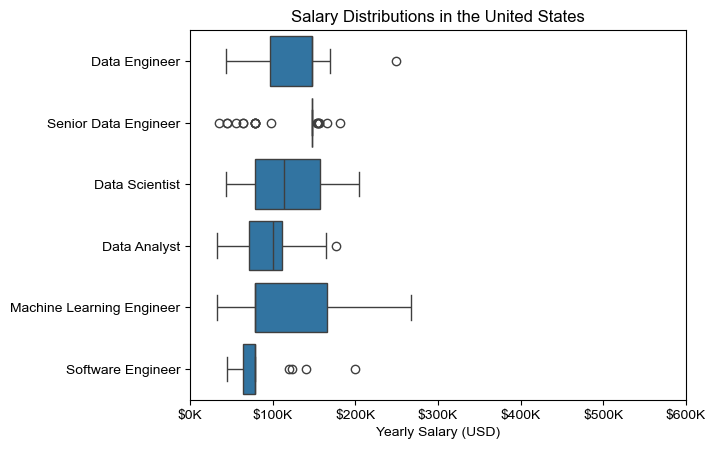

In [7]:
sns.boxplot(data=df_India_top6,x='salary_year_avg',y='job_title_short',order=job_order)
sns.set_theme(style='ticks')

# this is all the same
plt.title('Salary Distributions in the United States')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('')
plt.xlim(0, 600000)
ticks_x = plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K')
plt.gca().xaxis.set_major_formatter(ticks_x)

plt.show()

#### Investigate Median Salary Vs Skill for Data Analysts

In [4]:
df_DA_India = df[(df['job_title_short'] == 'Data Analyst') & (df['job_location'] == 'India')].copy()

In [5]:
df_DA_India = df_DA_India.dropna(subset='salary_year_avg')

In [6]:
df_DA_India = df_DA_India.explode('job_skills')

In [7]:
df_DA_top_pay = df_DA_India.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by='median',ascending=False)

df_DA_top_pay = df_DA_top_pay.head(10)

In [9]:
df_DA_top_skills = df_DA_India.groupby('job_skills')['salary_year_avg'].agg(['count','median']).sort_values(by='count',ascending=False)

df_DA_top_skills = df_DA_top_skills.head(10)

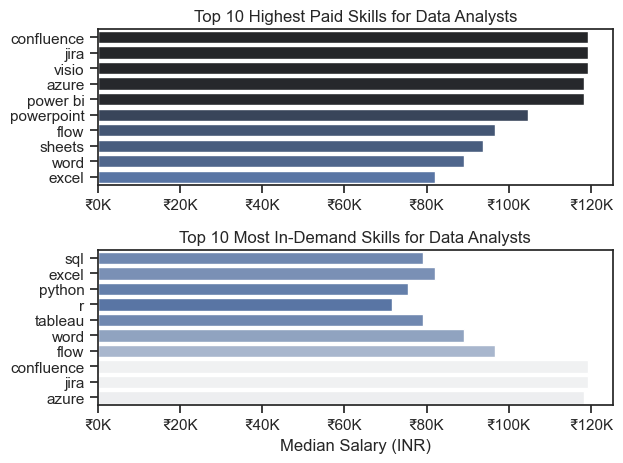

In [13]:
fig, ax= plt.subplots(2,1)
sns.set_theme(style='ticks')

# Top 10 highest Paid Skills for Data Analyst
sns.barplot(data=df_DA_top_pay,x='median',y=df_DA_top_pay.index, ax=ax[0], hue='median',palette='dark:b_r') 
# df_DA_top_pay[::-1].plot(kind='barh', y='median', ax=ax[0], legend=False)
ax[0].legend().remove()
ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax[0].set_ylabel('')
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{int(x/1000)}K'))

# Top 10 most In-Demand Skills for Data Analyst
sns.barplot(data=df_DA_top_skills,x='median',y=df_DA_top_skills.index, ax=ax[1], hue='median',palette='light:b_r')
ax[1].legend().remove()

# df_DA_top_skills.plot(kind='barh', y='median', ax=ax[1], legend=False)
ax[1].set_xlim(ax[0].get_xlim()) #this will set xlim similar to ax[0]'s lim
ax[1].set_title('Top 10 Most In-Demand Skills for Data Analysts')
ax[1].set_ylabel('')
ax[1].set_xlabel('Median Salary (INR)')
ax[1].set_xlim(ax[0].get_xlim())
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'₹{int(x/1000)}K'))

fig.tight_layout()